> Archived. This is the Stage 13 notebook from when the Karst Atlas connectivity score was version 2. It tests extensions to the Atlas score (watercourses, slope) against the Atlas baseline, and also holds the springs test and the Atlas-catchment check that now live in `13_connectivity_resolution.ipynb`. It is kept for the record: it reads the shared outputs of Stages 3 to 7 and was last run when they were last run, so re-running it needs the same outputs.

# Stage 13 — Connectivity: D8 routing (main) against the Atlas (version 2)

Stage 3 made D8 flow routing the main connectivity score and kept the Karst Atlas score (the highest of exposure type, proximal catchment and distal catchment) as version 2. This stage asks four questions about that choice:

1. **Can the Atlas score be improved?** Two extensions are tested against the Atlas baseline: a **watercourse signal** (natural streams from the LIST hydrolines, buffered by 50 m and scored by stream size: major stream or river 3, stream-sized tributary 2, minor tributary 1; it works at cell level) and a **slope factor** on the catchment signals (0.5 on flat catchments, 1 at 15 degrees or steeper, since steeper catchments deliver runoff more readily; exposed, covered and interstratal karst are not slope-scaled). The 50 m buffer, the stream-size scores and the 15 degree reference are judgements, and the direction of the slope effect is an assumption.
2. **Does the routing give the same answer at 2 m, 25 m and 100 m?** The scale story behind running it at 25 m locally and 100 m statewide.
3. **Do springs sit in high-D8 karst?** The same independent check as Stage 10, applied to the D8 ratio itself.
4. **Does the routing agree with the Atlas catchments?** D8 counts water arriving into a polygon, while the Atlas flags mark polygons whose own catchment drains onto karst, so the two are compared like for like: how much of the water reaching a polygon comes from an Atlas proximal catchment.

For the extensions, risk is recomputed with the Atlas score as the baseline (susceptibility, pressure and slope exactly as in the main method, connectivity swapped for the Atlas score). Slope needs care: the baseline carries the slope multiplier as a top-level factor, so the variants that put slope inside connectivity ("slope only" and "slope + watercourse") drop that multiplier, while the others keep it. Their correlations with the Atlas baseline therefore mix two things: the change to connectivity, and the different place where slope enters. The "watercourse only" row keeps the same slope treatment as the baseline, so it isolates the connectivity effect.

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.io import MemoryFile
from rasterio.mask import mask
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

sys.path.insert(0, str(Path("..") / "src"))
from karst import (add_karst_susceptibility, add_connectivity, add_connectivity_v2, add_connectivity_d8,
                   D8_LOG_EDGES, rasterize_max, in_mole_creek_focus, mole_creek_focus_mask,
                   aggregate_pressure_by_system)
from d8_routing import upstream_flag_counts
from hydro import load_watercourses, score_watercourses, watercourse_raster, mean_slope_by_polygon, slope_degrees, slope_risk_multiplier
from mapping import add_attribution, add_basemap, finish_map, raster_extent

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"

# Variants whose connectivity score already folds in slope (via add_connectivity_v2's
# per-polygon mean-slope scoring) skip the top-level slope factor below, so slope is
# never counted twice; variants without their own slope signal still get it, to stay
# comparable with the Atlas baseline (which carries the top-level factor).
SLOPE_IN_CONNECTIVITY = {"slope only", "slope + watercourse"}

def corr_nonzero(a, b, valid_mask):
    m = valid_mask & ~np.isnan(a) & ~np.isnan(b) & ((a > 0) | (b > 0))
    return np.corrcoef(a[m], b[m])[0, 1]

def named_ranking(risk, karst_only, shape, transform, valid_mask):
    profile = {"driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
               "dtype": "float32", "crs": "EPSG:7855", "transform": transform, "nodata": -9999}
    rows = []
    with MemoryFile() as mem:
        with mem.open(**profile) as dst:
            dst.write(np.where(valid_mask & ~np.isnan(risk), risk, -9999).astype("float32"), 1)
        with mem.open() as src:
            for name, group in karst_only.dropna(subset=["KNAME"]).groupby("KNAME"):
                img, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
                v = img[0]; v = v[v != -9999]
                rows.append({"KNAME": name, "mean_risk": v.mean() if len(v) else np.nan, "n_px": len(v)})
    return pd.DataFrame(rows).sort_values("mean_risk", ascending=False).reset_index(drop=True)

def variants(karst, conn_v1, conn_slope_poly, wc_cell, intensity):
    """Connectivity rasters: Atlas, slope only, watercourse only, both."""
    on_karst = intensity > 0
    return {
        "Atlas": conn_v1,
        "slope only": conn_slope_poly,
        "watercourse only": np.where(on_karst, np.maximum(conn_v1, wc_cell), conn_v1),
        "slope + watercourse": np.where(on_karst, np.maximum(conn_slope_poly, wc_cell), conn_slope_poly),
    }

## 13.1 Watercourses

The natural watercourses (LIST `HYDLNTY1 = Watercourse`) for all of Tasmania are read from the shared `watercourses_tas_EPSG7855.gpkg` in `Output_data`. If that file is missing, they are rebuilt from the 29 council hydroline files (about 15 minutes) and saved under the same name.

In [2]:
karst_tas = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas); add_connectivity(karst_tas)
# connectivity becomes the D8 score (main); connectivity_atlas keeps the Atlas score (version 2)
add_connectivity_d8(karst_tas, outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv", scheme="log")

shared = outpath / "watercourses_tas_EPSG7855.gpkg"
if shared.exists():
    wc = gpd.read_file(shared)
else:
    tas = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
    wc = load_watercourses(inpath / "Hydline", tuple(tas.total_bounds))
    wc.to_file(shared, driver="GPKG")
wc = score_watercourses(wc[wc["HYDLNTY1"] == "Watercourse"] if "HYDLNTY1" in wc.columns else wc)
print(f"Natural watercourses statewide: {len(wc)}")
print(wc["HYD_CLASS"].value_counts().to_string())

Natural watercourses statewide: 552028
HYD_CLASS
Minor Tributary    213226
Tributary          162122
Minor Stream        91855
Stream              49745
Major Stream        23134
Minor River          7578
River                2998
Major River          1312
N/A                    55


## 13.2 Mole Creek (25 m): extensions to the Atlas score

In [3]:
with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float)
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif") as src:
    conn_v1 = src.read(1).astype(float)
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1); dem_nodata = src.nodata; transform = src.transform; shape = dem.shape; cell = abs(src.transform.a)
with rasterio.open(outpath / "landuse_pressure_mc_2020_EPSG7855.tif") as src:
    pressure = src.read(1).astype(float); pressure_nodata = src.nodata

karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
focus = mole_creek_focus_mask(karst_mc, shape, transform)
valid = (dem != dem_nodata) & focus
karst_only = karst_mc[(karst_mc["karst_intensity"] > 0) & in_mole_creek_focus(karst_mc)]

slope = slope_degrees(dem, dem_nodata, cell)
add_connectivity_v2(karst_mc, mean_slope_by_polygon(karst_mc, slope, transform))
conn_slope_poly = rasterize_max(karst_mc, "connectivity_v2", shape, transform, fill=0, dtype="float32").astype(float)
mc_bounds = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg").total_bounds
wc_mc = wc.cx[mc_bounds[0]:mc_bounds[2], mc_bounds[1]:mc_bounds[3]]
wc_cell = watercourse_raster(wc_mc, shape, transform).astype(float)

conns = variants(karst_mc, conn_v1, conn_slope_poly, wc_cell, intensity)
print(f"Karst cells within 50 m of a mapped watercourse: {(wc_cell[valid] > 0).mean() * 100:.1f}%")
print(f"Mean slope factor on proximal-catchment polygons: {karst_mc.loc[karst_mc['proximal_score'] > 0, 'slope_factor'].mean():.2f} (1 = no reduction)")

# Atlas baseline: susceptibility x Atlas connectivity x aggregated pressure (x top-level slope).
# The top-level slope factor is applied only to variants whose connectivity does NOT already
# encode slope -- otherwise slope would count twice for "slope only" and "slope + watercourse".
top_level_slope_factor = slope_risk_multiplier(slope)
effective_pressure = aggregate_pressure_by_system(karst_mc, pressure, transform, pressure_nodata)
risk_base_noslope = np.where(valid, (intensity / 4.0) * (conn_v1 / 3.0) * (effective_pressure / 3.0), np.nan)
risk_base = risk_base_noslope * top_level_slope_factor

rows = []
risks_mc = {}
for name, c in conns.items():
    ratio = np.where(conn_v1 > 0, c / np.where(conn_v1 > 0, conn_v1, 1), 1.0)
    risk = risk_base_noslope * ratio
    if name not in SLOPE_IN_CONNECTIVITY:
        risk = risk * top_level_slope_factor
    risks_mc[name] = risk
    rows.append({"variant": name,
                 "mean connectivity": round(np.nanmean(c[valid]), 3),
                 "cells changed %": round((c[valid] != conn_v1[valid]).mean() * 100, 1),
                 "r vs Atlas risk": round(corr_nonzero(risk_base, risk, valid), 3),
                 "mean risk": round(np.nanmean(risk[valid]), 4)})
print(pd.DataFrame(rows).to_string(index=False))

table = named_ranking(risk_base, karst_only, shape, transform, valid).set_index("KNAME")[["mean_risk", "n_px"]].rename(columns={"mean_risk": "Atlas"})
for name in ["slope only", "watercourse only", "slope + watercourse"]:
    table[name] = named_ranking(risks_mc[name], karst_only, shape, transform, valid).set_index("KNAME")["mean_risk"]
print("\nMean risk by Mole Creek area:")
print(table.round(3).to_string())

Karst cells within 50 m of a mapped watercourse: 15.1%
Mean slope factor on proximal-catchment polygons: 0.80 (1 = no reduction)


            variant  mean connectivity  cells changed %  r vs Atlas risk  mean risk
              Atlas              2.387              0.0            1.000     0.1950
         slope only              2.320              8.7            0.860     0.3198
   watercourse only              2.411              2.4            0.991     0.1967
slope + watercourse              2.344             11.1            0.831     0.3232

Mean risk by Mole Creek area:
                              Atlas    n_px  slope only  watercourse only  slope + watercourse
KNAME                                                                                         
Mole Creek  (Chudleigh Hill)  0.268     214       0.484             0.268                0.484
Mole Creek                    0.202  388198       0.331             0.203                0.334
Meander - Western Creek       0.089   24111       0.143             0.089                0.143


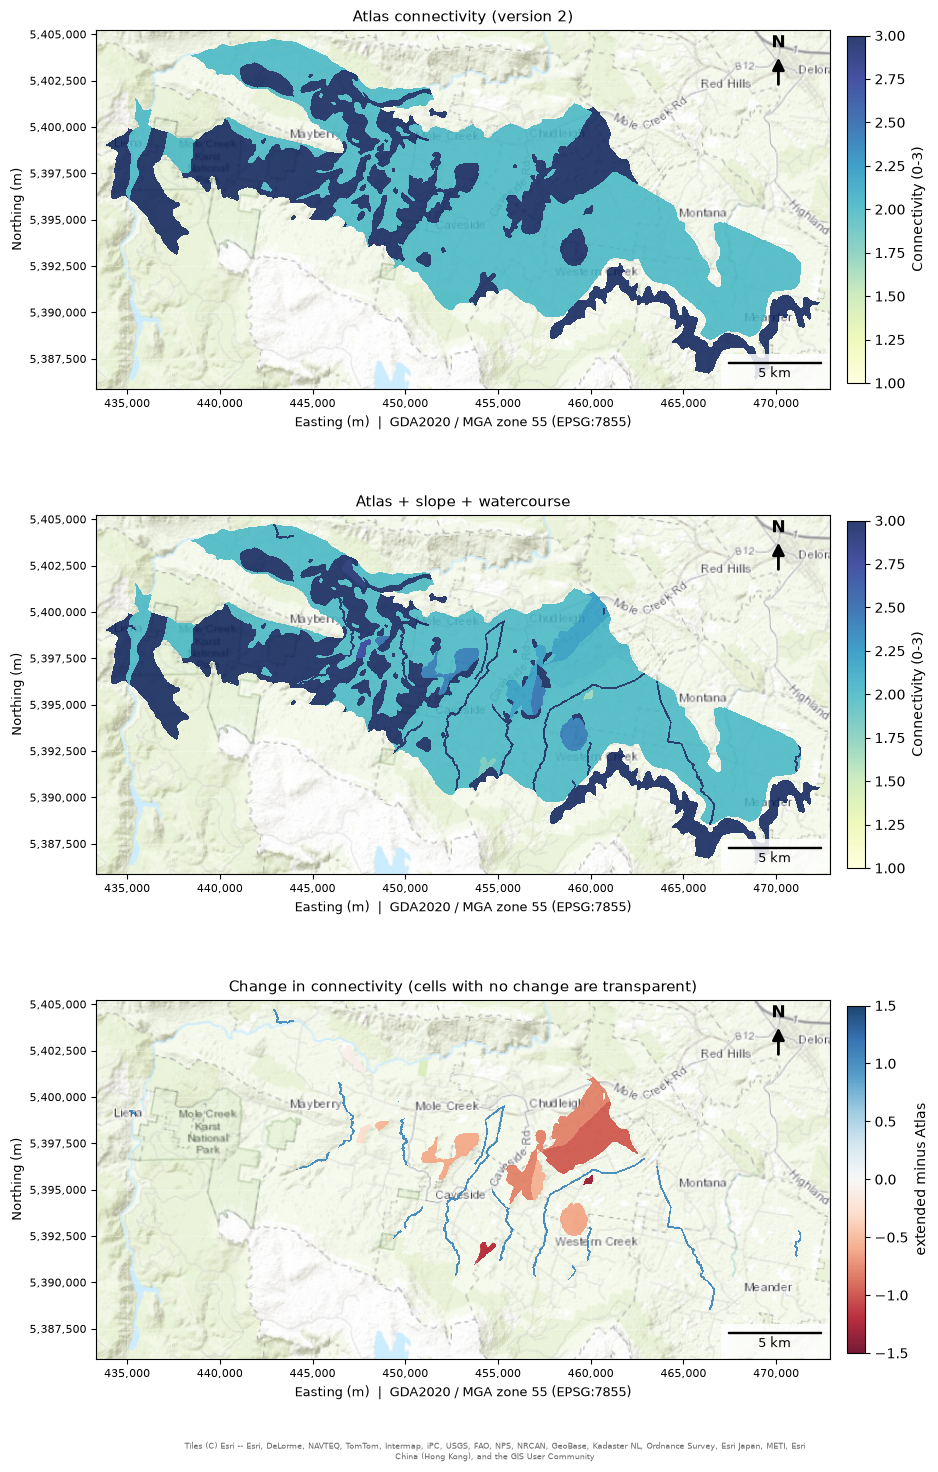

In [4]:
bounds = tuple(karst_only.total_bounds)
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
shown = {"Atlas connectivity (version 2)": conns["Atlas"], "Atlas + slope + watercourse": conns["slope + watercourse"]}
for ax, (title, arr) in zip(axes[:2], shown.items()):
    add_basemap(ax, bounds, margin=500, zoom=11)
    im = ax.imshow(np.ma.masked_where(~valid, arr), cmap="YlGnBu", vmin=1, vmax=3, alpha=0.85,
                   interpolation="nearest", extent=raster_extent(transform, shape), zorder=2)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="Connectivity (0-3)")
    ax.set_title(title, fontsize=11); finish_map(ax)
ax = axes[2]
diff = conns["slope + watercourse"] - conns["Atlas"]
add_basemap(ax, bounds, margin=500, zoom=11)
im = ax.imshow(np.ma.masked_where(~valid | (np.abs(diff) < 1e-9), diff), cmap="RdBu", vmin=-1.5, vmax=1.5, alpha=0.9,
               interpolation="nearest", extent=raster_extent(transform, shape), zorder=2)
fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="extended minus Atlas")
ax.set_title("Change in connectivity (cells with no change are transparent)", fontsize=11); finish_map(ax)
add_attribution(axes[-1])
plt.tight_layout(rect=(0, 0.02, 1, 1)); plt.show()

## 13.2b Does the resolution matter? The D8 routing at 2 m, 25 m and 100 m

The D8 routing follows the same method at three scales: `03alt2` (2 m DEM) and `03alt3` (25 m DEM) for the 66 core Mole Creek karst polygons, and the statewide 100 m run (`03-100m-hydrological-connectivity`) for all 1,677 mapped karst polygons. Comparing them over the 66 polygons they share shows whether the coarser grids lose what the finer grid sees. Each run counts, for a polygon, how many cells drain to it. The comparison uses the main score's five log classes (see Stage 3), the upstream area, and the ratio of upstream cells to the polygon's own cells.

In [5]:
d8_2m = pd.read_csv(outpath / "karst_upstream_connectivity_counts_core_mc_2m_EPSG7855_jenks5.csv")
d8_25m = pd.read_csv(outpath / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3_jenks5.csv")
both = d8_2m.merge(d8_25m, on="target_objectid", suffixes=("_2m", "_25m"))
print(f"Core targets matched between the 2 m and 25 m runs: {len(both)}")

def log_class(ratio):
    return np.digitize(ratio, D8_LOG_EDGES, right=True) + 1

s2 = log_class(both["upstream_cells_per_target_cell_2m"]); s25 = log_class(both["upstream_cells_per_target_cell_25m"])
print(f"\nLog class, 2 m:  {pd.Series(s2).value_counts().sort_index().to_dict()}")
print(f"Log class, 25 m: {pd.Series(s25).value_counts().sort_index().to_dict()}")
print(f"Same class at both resolutions: {(s2 == s25).mean() * 100:.0f}%; within one class: {(np.abs(s2 - s25) <= 1).mean() * 100:.0f}%")

a2, a25 = both["upstream_area_m2_2m"], both["upstream_area_m2_25m"]
print(f"\nUpstream area: rank correlation {spearmanr(a2, a25)[0]:.2f}, median 25 m / 2 m ratio {(a25 / a2).median():.2f}")
r2, r25 = both["upstream_cells_per_target_cell_2m"], both["upstream_cells_per_target_cell_25m"]
print(f"Upstream cells per target cell: rank correlation {spearmanr(r2, r25)[0]:.2f} (range {r2.max():.0f} at 2 m, {r25.max():.0f} at 25 m)")

d8_100m = pd.read_csv(outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv")
three = both.merge(d8_100m[["target_objectid", "upstream_area_m2", "target_raster_cells"]].rename(
    columns={"upstream_area_m2": "upstream_area_m2_100m", "target_raster_cells": "target_raster_cells_100m"}),
    on="target_objectid", how="left")
print(f"\nCore polygons also in the statewide 100 m run: {three['upstream_area_m2_100m'].notna().sum()} of {len(three)}")
print(f"Cells per core polygon at 100 m: median {three['target_raster_cells_100m'].median():.0f}; {(three['target_raster_cells_100m'] < 5).mean() * 100:.0f}% have fewer than 5")
print("\nUpstream area, rank correlation and median ratio between scales:")
for a, b, label in [("2m", "25m", "2 m vs 25 m"), ("25m", "100m", "25 m vs 100 m"), ("2m", "100m", "2 m vs 100 m")]:
    x, y = three[f"upstream_area_m2_{a}"], three[f"upstream_area_m2_{b}"]
    ok = x.notna() & y.notna()
    print(f"  {label:14s} rank correlation {spearmanr(x[ok], y[ok])[0]:.2f}, median ratio {(y[ok] / x[ok].replace(0, np.nan)).median():.2f} (n = {ok.sum()})")


Core targets matched between the 2 m and 25 m runs: 66

Log class, 2 m:  {1: 8, 2: 22, 3: 22, 4: 7, 5: 7}
Log class, 25 m: {1: 9, 2: 17, 3: 24, 4: 7, 5: 9}
Same class at both resolutions: 80%; within one class: 91%

Upstream area: rank correlation 0.81, median 25 m / 2 m ratio 1.00
Upstream cells per target cell: rank correlation 0.67 (range 197 at 2 m, 2303 at 25 m)

Core polygons also in the statewide 100 m run: 66 of 66
Cells per core polygon at 100 m: median 30; 12% have fewer than 5

Upstream area, rank correlation and median ratio between scales:
  2 m vs 25 m    rank correlation 0.81, median ratio 1.00 (n = 66)
  25 m vs 100 m  rank correlation 0.86, median ratio 0.96 (n = 66)
  2 m vs 100 m   rank correlation 0.86, median ratio 0.98 (n = 66)


**Result:** the D8 routing gives nearly the same answer at all three resolutions. Upstream area agrees across scales (rank correlation 0.81 between 2 m and 25 m, 0.86 between 25 m and 100 m, 0.86 between 2 m and 100 m, with median ratios of 0.96 to 1.00). At 25 m, 80% of the 66 polygons fall in the same log class as at 2 m and 91% within one class. The raw per-cell ratio agrees less (rank correlation 0.67 between 2 m and 25 m), partly because small polygons cover only a few 25 m cells, which inflates their ratio (up to about 2,300 at 25 m against 197 at 2 m).

So the coarser grids rank the targets almost as the 2 m grid does, which supports running this kind of signal at 25 m locally and 100 m statewide. They do not reproduce the fine detail inside a single target, and the 100 m grid is thin for small polygons: 12% of the core polygons have fewer than 5 cells, and 132 of the 1,677 statewide polygons (0.02% of karst area) have none.

## 13.3 Statewide (100 m): extensions to the Atlas score

In [6]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    tdem = src.read(1); tnodata = src.nodata; ttransform = src.transform; tshape = tdem.shape; tcell = abs(src.transform.a)
    land, _ = mask(src, tasmania.geometry, crop=False, nodata=tnodata)
tvalid = land[0] != tnodata
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    tmain = src.read(1).astype(float); rn = src.nodata
tmain = np.where(tvalid & (tmain != rn), tmain, np.nan)

t_int = rasterize_max(karst_tas, "karst_intensity", tshape, ttransform).astype(float)
t_conn_d8 = rasterize_max(karst_tas, "connectivity", tshape, ttransform, dtype="float32").astype(float)
t_conn1 = rasterize_max(karst_tas, "connectivity_atlas", tshape, ttransform).astype(float)   # Atlas baseline
tkarst = (t_int > 0) & tvalid
tkarst_only = karst_tas[karst_tas["karst_intensity"] > 0]

tslope = slope_degrees(tdem, tnodata, tcell)
add_connectivity_v2(karst_tas, mean_slope_by_polygon(karst_tas, tslope, ttransform))
t_conn_slope = rasterize_max(karst_tas, "connectivity_v2", tshape, ttransform, fill=0, dtype="float32").astype(float)
t_wc = watercourse_raster(wc, tshape, ttransform).astype(float)
tconns = variants(karst_tas, t_conn1, t_conn_slope, t_wc, t_int)
print(f"Karst cells within 50 m of a mapped watercourse: {(t_wc[tkarst] > 0).mean() * 100:.1f}%")
print(f"Mean slope factor on proximal-catchment polygons: {karst_tas.loc[karst_tas['proximal_score'] > 0, 'slope_factor'].mean():.2f}")

# The saved statewide raster is the main (D8) risk. Back out S x C(D8) x slope to get the effective
# pressure, then rebuild the Atlas baseline from it; the top-level slope factor is only applied to
# variants without their own slope signal (same reasoning as the Mole Creek cell above).
t_top_level_slope_factor = slope_risk_multiplier(tslope)
t_den = (t_int / 4.0) * (t_conn_d8 / 3.0) * t_top_level_slope_factor
t_eff = np.where(t_den > 0, tmain / np.where(t_den > 0, t_den, 1), 0.0)
tbase_noslope = (t_int / 4.0) * (t_conn1 / 3.0) * t_eff
tbase = np.where(tvalid, tbase_noslope * t_top_level_slope_factor, np.nan)

base_rank = named_ranking(tbase, tkarst_only, tshape, ttransform, tvalid)
rows = []; risks_t = {}
for name, c in tconns.items():
    ratio = np.where(t_conn1 > 0, c / np.where(t_conn1 > 0, t_conn1, 1), 1.0)
    risk = tbase_noslope * ratio
    if name not in SLOPE_IN_CONNECTIVITY:
        risk = risk * t_top_level_slope_factor
    risks_t[name] = risk
    rk = named_ranking(risk, tkarst_only, tshape, ttransform, tvalid)
    j = base_rank.merge(rk, on="KNAME", suffixes=("_b", "_v")); j = j[j["n_px_b"] >= 20]
    rows.append({"variant": name,
                 "mean connectivity (karst)": round(np.nanmean(c[tkarst]), 3),
                 "karst cells changed %": round((c[tkarst] != t_conn1[tkarst]).mean() * 100, 1),
                 "r vs Atlas risk": round(corr_nonzero(tbase, risk, tvalid), 3),
                 "Spearman, named areas": round(spearmanr(j["mean_risk_b"], j["mean_risk_v"], nan_policy="omit")[0], 3),
                 "mean risk (karst)": round(np.nanmean(risk[tkarst]), 4)})
print(pd.DataFrame(rows).to_string(index=False))

both = named_ranking(risks_t["slope + watercourse"], tkarst_only, tshape, ttransform, tvalid)
print("\nTop 10 named areas, Atlas vs Atlas + slope + watercourse:")
print(pd.concat([base_rank.head(10)[["KNAME", "mean_risk"]].reset_index(drop=True),
                 both.head(10)[["KNAME", "mean_risk"]].reset_index(drop=True).add_suffix(" (extended)")], axis=1).to_string())

Karst cells within 50 m of a mapped watercourse: 23.5%
Mean slope factor on proximal-catchment polygons: 0.77


            variant  mean connectivity (karst)  karst cells changed %  r vs Atlas risk  Spearman, named areas  mean risk (karst)
              Atlas                      2.559                    0.0            1.000                  1.000             0.1417
         slope only                      2.553                    1.0            0.929                  0.948             0.2430
   watercourse only                      2.578                    1.9            0.994                  0.999             0.1428
slope + watercourse                      2.572                    2.9            0.919                  0.940             0.2450



Top 10 named areas, Atlas vs Atlas + slope + watercourse:
                            KNAME  mean_risk             KNAME (extended)  mean_risk (extended)
0  Welcome River (1) / Port Hills   0.401318                 Geilston Bay              0.750000
1                   Doctors Rocks   0.395641                 Vinegar Hill              0.750000
2                    Vinegar Hill   0.378015           Emita - Memana (2)              0.694615
3                   Flowery Gully   0.369460                Doctors Rocks              0.647665
4                    Grim-Trefoil   0.364086  Irishtown - Sedgy Creek (2)              0.634849
5              Emita - Memana (2)   0.355048                 Grim-Trefoil              0.625000
6                      Port Hills   0.351189  Irishtown - Sedgy Creek (3)              0.613636
7                   South Pindars   0.323265                Flowery Gully              0.577099
8     Irishtown - Sedgy Creek (2)   0.321468                   Port Hills    

## Results: extensions to the Atlas score

- **Watercourses barely move the map.** About 15% of Mole Creek karst cells and 24% of karst cells statewide lie within 50 m of a mapped natural watercourse. On their own they change 2.4% of Mole Creek cells and 1.9% statewide, and the risk correlates with the Atlas risk at r = 0.99 in both places (rank correlation across named areas 0.999 statewide).
- **Slope inside connectivity changes the level more than the pattern.** It changes 8.7% of Mole Creek cells and 1.0% statewide. Its lower correlations with the Atlas risk (r = 0.86 at Mole Creek, 0.93 statewide) mostly reflect that the baseline applies slope as a top-level multiplier and these variants do not, so mean risk is higher (0.32 against 0.20 at Mole Creek).
- **Combined,** slope and watercourses give r = 0.83 at Mole Creek and 0.92 statewide against the Atlas risk.
- **Why so little changes:** most karst already scores 2 or 3 from its exposure type or a flagged proximal catchment, so under `max()` a stream or a slope scaling rarely becomes the largest signal. This is one reason the Atlas score is a weak discriminator and a routed score was preferred as the main connectivity.

## 13.4 Do springs sit in high-D8 karst? The springs test

The statewide 100 m D8 run makes it possible to test the D8 signal against the same independent check used in Stage 10. The raw upstream area mostly measures polygon size, so the test uses the number of upstream cells per cell of the polygon itself. Each polygon is scored by its percentile rank on that ratio; springs within 500 m take the score of their nearest polygon; one value per named system is compared with 10,000 random same-size draws of polygons (weighted by area). The main intrinsic score (susceptibility x D8 class) and the Atlas intrinsic score are tested on exactly the same polygons for comparison.

In [7]:
from scipy.stats import rankdata

d8_all = pd.read_csv(outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv")
kp = karst_tas[karst_tas["karst_intensity"] > 0].merge(
    d8_all[["target_objectid", "target_raster_cells", "upstream_cell_count"]], left_on="OBJECTID", right_on="target_objectid")
kp["area"] = kp.geometry.area
none_cells = kp["target_raster_cells"] == 0
print(f"Karst polygons with a 100 m D8 count: {len(kp)}; none has a cell on the 100 m grid: {none_cells.sum()} ({kp.loc[none_cells, 'area'].sum() / kp['area'].sum() * 100:.2f}% of karst area), excluded")
kp = kp[~none_cells].copy()
kp["d8_ratio"] = kp["upstream_cell_count"] / kp["target_raster_cells"]
kp["main_intrinsic"] = (kp["karst_intensity"] / 4.0) * (kp["connectivity"] / 3.0)
kp["atlas_intrinsic"] = (kp["karst_intensity"] / 4.0) * (kp["connectivity_atlas"] / 3.0)
print(f"D8 ratio against polygon size: rank correlation {spearmanr(kp['d8_ratio'], kp['area'])[0]:.2f}; against the Atlas intrinsic score: {spearmanr(kp['d8_ratio'], kp['atlas_intrinsic'])[0]:.2f}")

gde = gpd.read_file(inpath / "LIST_CFEV_GROUNDWATER_STATEWIDE/list_cfev_groundwater_statewide.shp").to_crs("EPSG:7855")
gde = gpd.clip(gde, gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg"))
core_types = ["Tufa-depositing spring", "Cold spring", "Subsurface stream"]
rng = np.random.default_rng(42)

def springs_percentile(col, types=None, max_dist=500):
    pct_rank = rankdata(kp[col]) / len(kp)
    polys = kp[["KNAME", "geometry"]].assign(v=pct_rank)
    pts = gde if types is None else gde[gde["GDE_TYPE"].isin(types)]
    near = gpd.sjoin_nearest(pts, polys, how="left", distance_col="dist_m")
    near = near[~near.index.duplicated(keep="first")]
    near = near[near["dist_m"] <= max_dist]
    by_system = near.groupby("KNAME")["v"].mean()
    weights = (kp["area"] / kp["area"].sum()).to_numpy()
    null = pct_rank[rng.choice(len(kp), size=(10000, len(by_system)), p=weights)].mean(axis=1)
    return len(by_system), (null < by_system.mean()).mean() * 100

rows = []
for col, label in [("d8_ratio", "D8 upstream cells per target cell"), ("main_intrinsic", "Main intrinsic score (D8 log classes x susceptibility)"), ("atlas_intrinsic", "Atlas intrinsic score (same polygons)")]:
    for type_label, types in [("all types", None), ("core types", core_types)]:
        n_sys, pct = springs_percentile(col, types)
        rows.append({"signal": label, "springs": type_label, "systems": n_sys, "percentile": round(pct, 1)})
print("\n" + pd.DataFrame(rows).to_string(index=False))

Karst polygons with a 100 m D8 count: 1677; none has a cell on the 100 m grid: 132 (0.02% of karst area), excluded
D8 ratio against polygon size: rank correlation 0.02; against the Atlas intrinsic score: 0.05



                                                signal    springs  systems  percentile
                     D8 upstream cells per target cell  all types       24        69.6
                     D8 upstream cells per target cell core types       17        46.4
Main intrinsic score (D8 log classes x susceptibility)  all types       24        88.2
Main intrinsic score (D8 log classes x susceptibility) core types       17        84.0
                 Atlas intrinsic score (same polygons)  all types       24        98.5
                 Atlas intrinsic score (same polygons) core types       17        99.1


**Result:** the D8 ratio measures something different from the Atlas score. It is unrelated to polygon size (rank correlation 0.02) and to the Atlas intrinsic score (0.05). The ratio alone does not predict where springs are: they sit near the middle of its distribution (about the 70th percentile for all spring types, the 46th for the core types). The main intrinsic score (susceptibility times the D8 class) does better, at the 88th (all types) and 84th (core types) percentile, but both sit below the Atlas intrinsic score on the same polygons (98.5th and 99.1st). Stage 10 tests the main score against the same springs with an area-weighted null on the intrinsic values themselves and gets the 95th and 91st percentile.

Springs mark where water emerges, not where it enters, so this is a weak test for a recharge signal. It does mean the move from the Atlas to D8 as the main connectivity costs some agreement with the springs, and that the D8 score still has no independent validation of its own. The scale result in 13.2b shows the routing is stable across resolution, and 13.5 shows it is consistent with the Atlas catchments.

## 13.5 Does the routing agree with the Atlas catchments? A like-for-like check

The raw D8 ratio and the Atlas connectivity score point in different directions: the ratio measures water arriving **into** a polygon, whereas `KPROXCATCH` marks polygons that drain **onto** karst. They should not be expected to rank polygons the same way, and they do not (rank correlations below). The like-for-like question is different: of the cells that D8 routes into a polygon from outside it, how many lie inside Atlas proximal catchments? If the Atlas catchments are a fair map of where karst water comes from, that share should be well above the proximal catchments' share of the landscape.

The 25 m run already records this count (the saved 2 m file does not separate the polygons' own cells, so it is left out). For the 100 m run it is computed here from the saved D8 pointer and the proximal-catchment raster (`d8_routing.upstream_flag_counts`), and cached.

In [8]:
def external_share(df, upstream_flag_col):
    """Water arriving from outside each polygon: total cells, and the flagged part."""
    outside = df["upstream_cell_count"] - (df["target_raster_cells"] - df["target_cells_excluded_from_total"])
    return pd.DataFrame({"outside": outside, "flagged": df[upstream_flag_col]}).assign(target_objectid=df["target_objectid"])

# 100 m statewide: compute (or reuse) the flagged counts from the saved D8 pointer
cache_100m = outpath / "karst_upstream_proximal_counts_tas_100m_EPSG7855.csv"
targets_100m = karst_tas[karst_tas["karst_intensity"] > 0].reset_index(drop=True)
if cache_100m.is_file():
    flag_100m = pd.read_csv(cache_100m)
else:
    flag_100m = upstream_flag_counts(outpath / "d8_pointer_tas_100m_EPSG7855.tif", targets_100m,
                                     outpath / "kproxcatch_presence_tas_100m_EPSG7855.tif")
    flag_100m.to_csv(cache_100m, index=False)
f100 = flag_100m.rename(columns={"OBJECTID": "target_objectid", "upstream_cells": "outside", "upstream_flagged": "flagged"})
f100 = f100[f100["target_cells"] > 0][["target_objectid", "outside", "flagged"]]

d8_25m_raw = pd.read_csv(outpath / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3.csv")
f25 = external_share(d8_25m_raw, "upstream_kproxcatch_cells_excluding_target")
d8_100m_all = pd.read_csv(outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv")

with rasterio.open(outpath / "kproxcatch_presence_tas_100m_EPSG7855.tif") as src:
    kp_grid = src.read(1)
with rasterio.open(outpath / "d8_pointer_tas_100m_EPSG7855.tif") as src:
    ptr_valid = src.read(1) != src.nodata
share_of_landscape = ((kp_grid == 1) & ptr_valid).sum() / ptr_valid.sum()

atlas_score = karst_tas.set_index("OBJECTID")["connectivity_atlas"]
rows = []
for label, f, ratio_df in [("Mole Creek 25 m", f25, d8_25m_raw), ("Tasmania 100 m", f100, d8_100m_all)]:
    e = f[f["outside"] > 0]
    r = ratio_df.set_index("target_objectid")["upstream_cells_per_target_cell"].dropna()
    a = atlas_score.reindex(r.index)
    rows.append({"run": label, "polygons with outside drainage": len(e),
                 "receive from proximal catchment %": round((e["flagged"] > 0).mean() * 100, 1),
                 "median share of outside drainage %": round((e["flagged"] / e["outside"]).median() * 100, 1),
                 "pooled share %": round(e["flagged"].sum() / e["outside"].sum() * 100, 1),
                 "rank corr, D8 ratio vs Atlas score": round(spearmanr(r.loc[a.notna()], a.dropna())[0], 2)})
print(f"Proximal catchments cover {share_of_landscape * 100:.1f}% of the statewide valid cells (the share expected by chance).\n")
print(pd.DataFrame(rows).to_string(index=False))

Proximal catchments cover 11.1% of the statewide valid cells (the share expected by chance).

            run  polygons with outside drainage  receive from proximal catchment %  median share of outside drainage %  pooled share %  rank corr, D8 ratio vs Atlas score
Mole Creek 25 m                              63                               92.1                                73.1            67.8                               -0.21
 Tasmania 100 m                            1410                               81.1                                74.5            27.5                               -0.10


**Result:** the Atlas proximal catchments are a fair map of where the routed water comes from. At Mole Creek (25 m), 92% of the 63 polygons with drainage arriving from outside receive some of it from an Atlas proximal catchment, and a median of 73% (67.8% pooled) of that outside drainage lies in them. Statewide (100 m), 81% of the 1,410 such polygons receive from a proximal catchment, with a median share of 74.5% and a pooled share of 27.5%. Proximal catchments cover only 11.1% of the statewide landscape, so the pooled share is about 2.5 times what chance would give.

The raw scores still do not agree: the rank correlation between the D8 ratio and the Atlas score is -0.21 at Mole Creek and -0.10 statewide. That is expected, because the ratio rewards karst low in a large catchment, whereas the Atlas flags mark the source side, so a polygon flagged proximal is typically a headwater with little drainage arriving. The two are complementary views of the same system, not competing estimates of one quantity. The routed score is the better main choice because it varies across the karst (the Atlas puts most Mole Creek polygons at the maximum, 3), and the Atlas stays available as version 2.

**Limitations.** Own cells are removed from both counts, because 60% of polygons are themselves flagged and including them would inflate the overlap. The 100 m run drops the 132 polygons too small for a cell, and the saved 2 m file does not separate own cells, so this check is run at 25 m and 100 m only.